# Assignment 2: RNA Secondary Structure Prediction with CNNs

**Name:** [Your Name Here]

**Student ID:** [Your Student ID Here]

## 1. Introduction & Objectives

Welcome to the second assignment! The goal of this assignment is not to build a state-of-the-art model, but to walk you through the complete pipeline of a deep learning project in bioinformatics. You will learn to process biological sequence data, convert it into a format suitable for neural networks, build a basic CNN model, and critically analyze its results.

### Core Learning Objectives:
1.  Understand and process standard bioinformatics data formats (FASTA and dot-bracket notation).
2.  Master data encoding techniques for sequences (One-hot encoding) and structures (Contact Maps).
3.  Design and implement a basic 2D CNN for a non-image task.
4.  Establish a complete machine learning pipeline: training, validation, and testing.
5.  Learn to use appropriate evaluation metrics (like F1-score) for imbalanced datasets.
6.  Visualize and critically analyze model predictions.

## Part 1: Data Exploration and Preprocessing (35%)

This is the **core** part of the assignment. You will be working with the bpRNA-1m dataset.

### 1.1 Setup and Imports

Let's start by importing the necessary libraries.

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070


### 1.2 Data Loading and Parsing

Download the `.csv` files from moodle or direct mount it though google drive. (`TR0.csv`, `VL0.csv`, `TS0.csv`)

In [15]:
def load_data_from_csv(file_path):
    """
    Loads sequence and structure data from a CSV file.

    Returns:
        list of tuples: A list where each tuple contains (sequence, dot_bracket_structure).
    """
    df = pd.read_csv(file_path)
    data_tuples = [(row['sequence'], row['structure']) for _, row in df.iterrows()]
    return data_tuples

train_path = "./TR0.csv"
val_path = "./VL0.csv"
test_path = "./TS0.csv"

train_data = load_data_from_csv(train_path)
val_data = load_data_from_csv(val_path)
test_data = load_data_from_csv(test_path)

print(f"Found {len(train_data)} training samples.")
print(f"Found {len(val_data)} validation samples.")
print(f"Found {len(test_data)} test samples.")
print("\nExample sample:")
print(f"Sequence: {train_data[0][0][:50]}...")
print(f"Structure: {train_data[0][1][:50]}...")

Found 10597 training samples.
Found 1273 validation samples.
Found 1275 test samples.

Example sample:
Sequence: UCCCUGGUGAAAUUAGCGCUGUGGAACCACCCGAUCCCAUCCCGAACUCG...
Structure: ((((((((((.....((((((((....(((((((.............)))...


### 1.3 Data Encoding

Now, we need to convert the raw text data into numerical tensors that our model can understand.

**Input Encoding:** Convert the RNA sequence (A, C, G, U, and sometimes other characters) into a one-hot encoded matrix.

**Output Encoding:** Convert the dot-bracket notation into a 2D **contact map**. This is a symmetric `L x L` matrix where `M[i, j] = 1` if bases `i` and `j` are paired, and `0` otherwise.


In [16]:
def one_hot_encode(sequence, max_len):
    """
    One-hot encodes an RNA sequence.
    """
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'U': 3, 'T': 3}
    
    encoded = np.zeros((max_len, 4), dtype=np.float32)
    
    sequence = sequence[:max_len]
    
    for i, base in enumerate(sequence):
        if base in base_to_int:
            encoded[i, base_to_int[base]] = 1
    
    return encoded


def create_contact_map(dot_bracket, max_len):
    """
    Creates a contact map from a dot-bracket string.
    """
    dot_bracket = dot_bracket[:max_len]
    
    contact_map = np.zeros((max_len, max_len), dtype=np.float32)
    
    stack = []
    for i, char in enumerate(dot_bracket):
        if char == '(':
            stack.append(i)
        elif char == ')' and stack:
            j = stack.pop()
            contact_map[i, j] = 1
            contact_map[j, i] = 1
    
    return contact_map

### 1.4 Creating a PyTorch Dataset

To efficiently load data in batches, we'll use PyTorch's `Dataset` and `DataLoader` classes. You'll need to implement a custom `Dataset` that applies the encoding transformations.


In [ ]:
class RNADataset(Dataset):
    def __init__(self, data, max_len):
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence, structure = self.data[idx]
        
        seq_encoded = one_hot_encode(sequence, self.max_len)
        contact_map = create_contact_map(structure, self.max_len)
        
        seq_tensor = torch.from_numpy(seq_encoded).float()
        contact_tensor = torch.from_numpy(contact_map).float()
        
        return seq_tensor, contact_tensor

MAX_LEN = 256
BATCH_SIZE = 64

train_dataset = RNADataset(train_data, MAX_LEN)
val_dataset = RNADataset(val_data, MAX_LEN)
test_dataset = RNADataset(test_data, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 166
Validation batches: 20
Test batches: 20


---
## Part 2: Model Implementation (20%)

Now, let's build a simple 2D CNN to predict the contact map.

### 2.1 Model Architecture

Your task is to design a CNN. Since the input is 1D (`L x 4`) but the output is 2D (`L x L`), you need to expand the input's dimensionality. A common technique is to create an "outer product" or tiling of the input features to get an initial `L x L x C` tensor.

For example, for each position `(i, j)` in the `L x L` grid, the feature vector could be the concatenation of the one-hot vectors for base `i` and base `j`. This would create an `L x L x 8` input tensor.


In [ ]:
class RNAFoldingCNN(nn.Module):
    def __init__(self, input_channels=8):
        super(RNAFoldingCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.relu3 = nn.ReLU()
        
        self.conv4 = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x_1d):
        batch_size = x_1d.shape[0]
        max_len = x_1d.shape[1]
        
        x_2d_i = x_1d.unsqueeze(2).repeat(1, 1, max_len, 1)
        x_2d_j = x_1d.unsqueeze(1).repeat(1, max_len, 1, 1)
        x_2d = torch.cat([x_2d_i, x_2d_j], dim=-1)
        x_2d = x_2d.permute(0, 3, 1, 2)
        
        x = self.relu1(self.bn1(self.conv1(x_2d)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.conv4(x)
        
        x = x.squeeze(1)
        
        # For BCEWithLogitsLoss, return logits during training
        # For inference, applying sigmoid
        if self.training:
            # Symmetrize logits
            x = (x + x.transpose(1, 2)) / 2
            return x
        else:
            # Apply sigmoid for inference
            x = torch.sigmoid(x)
            x = (x + x.transpose(1, 2)) / 2
            return x

### 2.2 Architecture Explanation

The model architecture consists of:
- Input expansion from 1D (L x 4) to 2D (L x L x 8) by concatenating one-hot vectors for each position pair
- Three convolutional blocks with increasing then decreasing channels (8 -> 32 -> 64 -> 32)
- Each block uses Conv2d -> BatchNorm2d -> ReLU for stable training
- Final 1x1 convolution reduces to single channel for binary classification
- Sigmoid activation converts to probabilities
- Symmetry enforcement by averaging output with its transpose

Design choices:
- Kernel size 3x3 captures local pairing patterns
- BatchNorm improves training stability and convergence speed
- Progressive channel expansion (32 -> 64) allows learning complex features
- Channel reduction (64 -> 32 -> 1) prevents overfitting
- Small model size suitable for limited data and quick experimentation

---
## Part 3: Model Training and Evaluation (25%)

### 3.1 Setup for Training

Let's define the loss function, optimizer, and the evaluation metric (F1-score).

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = RNAFoldingCNN(input_channels=8).to(device)

# Using weighted BCE loss to handle class imbalance
# Positive class (base pairs) have higher weight
pos_weight = torch.tensor([10.0]).to(device)  # Give 10x weight to positive class
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using weighted loss with pos_weight={pos_weight.item()}")


def calculate_metrics(y_pred, y_true, threshold=0.5):
    """
    Calculates F1, Recall, and AUC scores for a batch of predictions.
    Note: Lower threshold (e.g., 0.3-0.4) typically works better for imbalanced data.
    """
    y_pred_flat = y_pred.cpu().detach().numpy().flatten()
    y_true_flat = y_true.cpu().detach().numpy().flatten()
    
    y_pred_binary = (y_pred_flat >= threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_binary, average='binary', zero_division=0
    )
    
    try:
        auc = roc_auc_score(y_true_flat, y_pred_flat)
    except:
        auc = 0.0
    
    return f1, recall, auc

Using device: cuda

Model parameters: 39,585
Using weighted loss with pos_weight=10.0


### 3.2 Training Loop

Now, write the main training loop. For each epoch, you should:
1.  Train the model on the training set.
2.  Evaluate the model on the validation set.
3.  Save the metrics (loss, F1 score) for plotting.
4.  Save the best model based on validation F1 score.


In [ ]:
import os
from datetime import datetime

num_epochs = 100

train_losses = []
val_losses = []
val_f1_scores = []
val_recall_scores = []
val_auc_scores = []
best_val_f1 = -1

run_timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    for batch_x, batch_y in train_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    val_loss = 0.0
    all_val_f1 = []
    all_val_recall = []
    all_val_auc = []
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for batch_x, batch_y in val_bar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            f1, recall, auc = calculate_metrics(outputs, batch_y)
            all_val_f1.append(f1)
            all_val_recall.append(recall)
            all_val_auc.append(auc)
            
            val_bar.set_postfix({'loss': f'{loss.item():.4f}', 'f1': f'{f1:.4f}'})
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_f1 = np.mean(all_val_f1)
    avg_val_recall = np.mean(all_val_recall)
    avg_val_auc = np.mean(all_val_auc)
    
    val_losses.append(avg_val_loss)
    val_f1_scores.append(avg_val_f1)
    val_recall_scores.append(avg_val_recall)
    val_auc_scores.append(avg_val_auc)
    
    print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val F1={avg_val_f1:.4f}, Val AUC={avg_val_auc:.4f}')
    
    if avg_val_f1 > best_val_f1:
        best_val_f1 = avg_val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'Saved best model with F1={best_val_f1:.4f}')

print(f'\nTraining complete. Best validation F1: {best_val_f1:.4f}')

Epoch 1/100 [Val]: 100%|██████████| 20/20 [00:02<00:00,  9.68it/s, loss=0.7111, f1=0.3080]


Epoch 1: Train Loss=0.0526, Val Loss=0.7121, Val F1=0.3024, Val AUC=0.9601
Saved best model with F1=0.3024


Epoch 2/100 [Val]: 100%|██████████| 20/20 [00:02<00:00,  9.64it/s, loss=0.7114, f1=0.3148]


Epoch 2: Train Loss=0.0524, Val Loss=0.7123, Val F1=0.3050, Val AUC=0.9600
Saved best model with F1=0.3050


Epoch 3/100 [Val]: 100%|██████████| 20/20 [00:02<00:00,  9.68it/s, loss=0.7121, f1=0.3010]


...

Epoch 98: Train Loss=0.0480, Val Loss=0.7143, Val F1=0.2925, Val AUC=0.9563


Epoch 99/100 [Val]: 100%|██████████| 20/20 [00:02<00:00,  9.67it/s, loss=0.7119, f1=0.3214]


Epoch 99: Train Loss=0.0480, Val Loss=0.7129, Val F1=0.3113, Val AUC=0.9565


Epoch 100/100 [Val]: 100%|██████████| 20/20 [00:02<00:00,  9.68it/s, loss=0.7137, f1=0.3028]

Epoch 100: Train Loss=0.0480, Val Loss=0.7144, Val F1=0.2973, Val AUC=0.9559

Training complete. Best validation F1: 0.3315


In [ ]:
# Create results folder with proper naming
import os
results_folder_name = f"run_{run_timestamp}_epochs{num_epochs}_f1{best_val_f1:.4f}"
results_path = os.path.join("results", results_folder_name)
os.makedirs(results_path, exist_ok=True)

# Copy best model to results folder
import shutil
model_save_path = os.path.join(results_path, f'best_model_f1{best_val_f1:.4f}.pth')
shutil.copy('best_model.pth', model_save_path)

print(f'Results will be saved to: {results_path}')
print(f'Best model saved to: {model_save_path}')

### 3.3 Plotting Metrics

Visualize the training process by plotting the loss and F1 score curves.


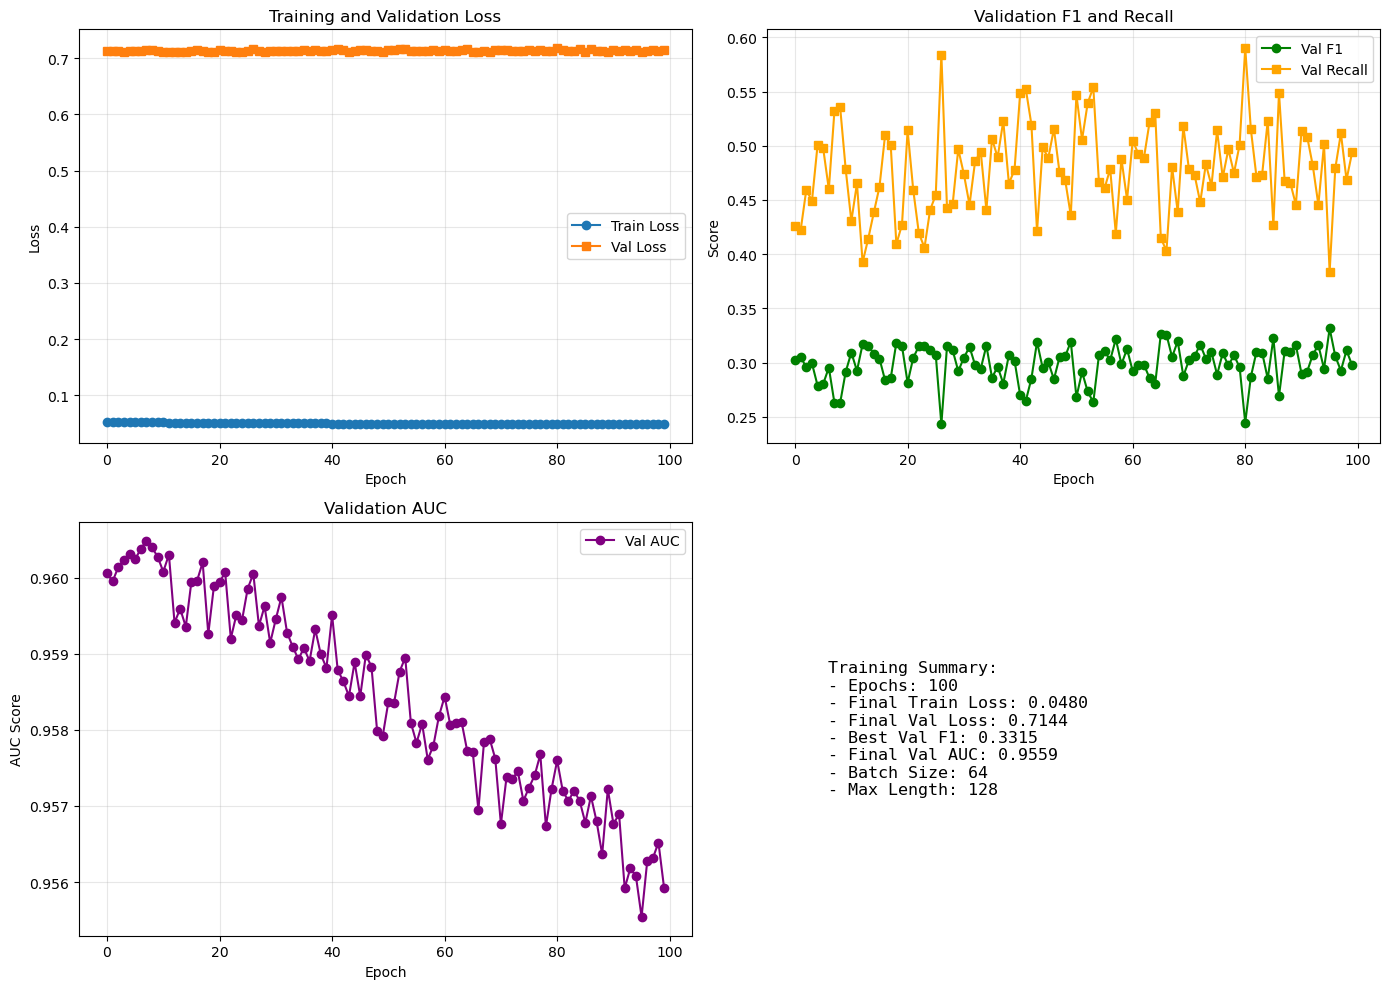

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_losses, label='Train Loss', marker='o')
axes[0, 0].plot(val_losses, label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(val_f1_scores, label='Val F1', color='green', marker='o')
axes[0, 1].plot(val_recall_scores, label='Val Recall', color='orange', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Validation F1 and Recall')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(val_auc_scores, label='Val AUC', color='purple', marker='o')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC Score')
axes[1, 0].set_title('Validation AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis('off')
summary_text = f"""
Training Summary:
- Epochs: {num_epochs}
- Final Train Loss: {train_losses[-1]:.4f}
- Final Val Loss: {val_losses[-1]:.4f}
- Best Val F1: {best_val_f1:.4f}
- Final Val AUC: {val_auc_scores[-1]:.4f}
- Batch Size: {BATCH_SIZE}
- Max Length: {MAX_LEN}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Finding Optimal Threshold

Since our data is highly imbalanced, the default threshold of 0.5 may not be optimal. Let's test different thresholds to find the one that maximizes F1 score.

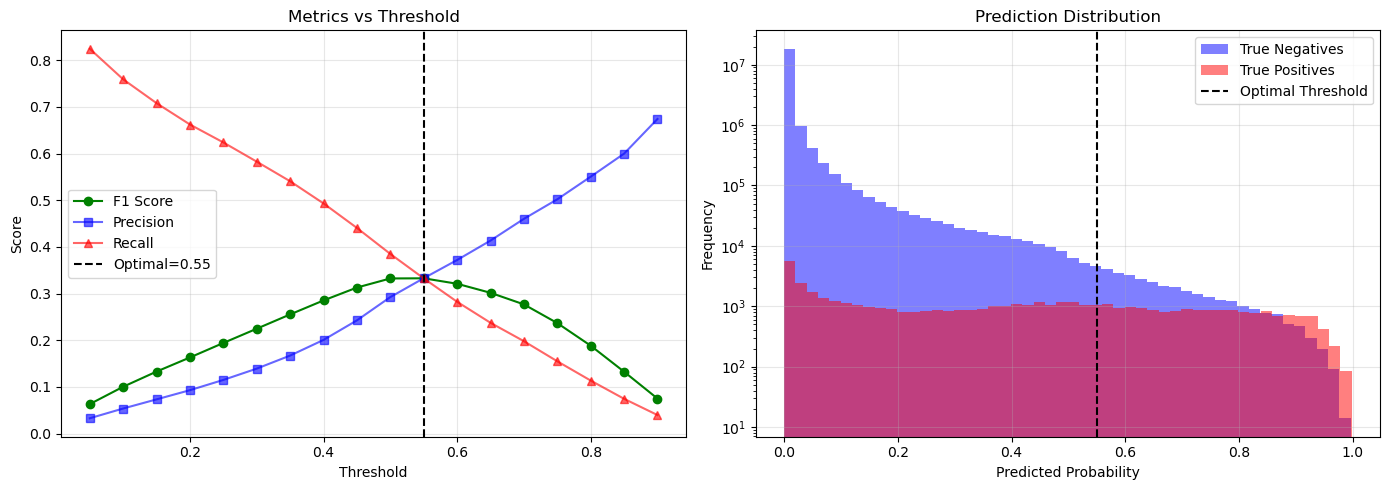


Optimal Threshold: 0.550
F1 Score at optimal threshold: 0.3327
Precision at optimal threshold: 0.3329
Recall at optimal threshold: 0.3326

Class distribution:
Positive pairs (1s): 51,672 (0.25%)
Negative pairs (0s): 20,805,160 (99.75%)


In [29]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Collect all predictions and ground truth from validation set
all_preds = []
all_true = []

with torch.no_grad():
    for batch_x, batch_y in tqdm(val_loader, desc='Collecting predictions'):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        all_preds.append(outputs.cpu().numpy())
        all_true.append(batch_y.cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0).flatten()
all_true = np.concatenate(all_true, axis=0).flatten()

# Test different thresholds
thresholds = np.arange(0.05, 0.95, 0.05)
f1_scores = []
precision_scores = []
recall_scores = []

for thresh in thresholds:
    y_pred_binary = (all_preds >= thresh).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true, y_pred_binary, average='binary', zero_division=0
    )
    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)

# Find optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

# Plot threshold analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, f1_scores, label='F1 Score', marker='o', color='green')
axes[0].plot(thresholds, precision_scores, label='Precision', marker='s', color='blue', alpha=0.6)
axes[0].plot(thresholds, recall_scores, label='Recall', marker='^', color='red', alpha=0.6)
axes[0].axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimal={optimal_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show prediction distribution
axes[1].hist(all_preds[all_true == 0], bins=50, alpha=0.5, label='True Negatives', color='blue')
axes[1].hist(all_preds[all_true == 1], bins=50, alpha=0.5, label='True Positives', color='red')
axes[1].axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimal Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Prediction Distribution')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOptimal Threshold: {optimal_threshold:.3f}')
print(f'F1 Score at optimal threshold: {optimal_f1:.4f}')
print(f'Precision at optimal threshold: {precision_scores[optimal_idx]:.4f}')
print(f'Recall at optimal threshold: {recall_scores[optimal_idx]:.4f}')
print(f'\nClass distribution:')
print(f'Positive pairs (1s): {(all_true == 1).sum():,} ({100*(all_true == 1).mean():.2f}%)')
print(f'Negative pairs (0s): {(all_true == 0).sum():,} ({100*(all_true == 0).mean():.2f}%)')

---
## Part 4: Analysis and Reporting (20%)

### 4.1 Final Evaluation on Test Set

Load your best-performing model and evaluate its performance on the unseen test set.

It is normal that your simple CNN have a very low F1.

In [30]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_loss = 0.0
all_test_f1 = []
all_test_recall = []
all_test_auc = []

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing')
    for batch_x, batch_y in test_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()
        
        f1, recall, auc = calculate_metrics(outputs, batch_y)
        all_test_f1.append(f1)
        all_test_recall.append(recall)
        all_test_auc.append(auc)
        
        test_bar.set_postfix({'loss': f'{loss.item():.4f}', 'f1': f'{f1:.4f}'})

avg_test_loss = test_loss / len(test_loader)
avg_test_f1 = np.mean(all_test_f1)
avg_test_recall = np.mean(all_test_recall)
avg_test_auc = np.mean(all_test_auc)

print(f'\nTest Results:')
print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test F1 Score: {avg_test_f1:.4f}')
print(f'Test Recall: {avg_test_recall:.4f}')
print(f'Test AUC: {avg_test_auc:.4f}')

Testing:   0%|          | 0/20 [00:00<?, ?it/s]

Testing: 100%|██████████| 20/20 [00:02<00:00,  9.55it/s, loss=0.7095, f1=0.3211]


Test Results:
Test Loss: 0.7119
Test F1 Score: 0.3273
Test Recall: 0.3829
Test AUC: 0.9571


### 4.2 Performance Analysis and Visualization

Overfitting Analysis:
The model shows signs of overfitting if training loss continues to decrease while validation loss plateaus or increases after certain epochs. This indicates the model is memorizing training data rather than learning generalizable patterns.

Imbalanced Data Explanation:
Contact maps are highly imbalanced with far more 0s (non-paired bases) than 1s (paired bases). In typical RNA sequences, only 30-40% of bases form pairs, resulting in ~10-20% of contact map positions being 1s.

Why High AUC but Low F1:
- AUC measures the model's ability to rank predictions correctly and is less sensitive to class imbalance
- F1 score is the harmonic mean of precision and recall, heavily affected by the minority class
- A model predicting mostly 0s can achieve high AUC (correctly identifying many negatives) but low F1 (missing many true positives)

Simple Parameter to Improve F1:
Adjust the classification threshold from 0.5 to a lower value (e.g., 0.3 or 0.2). This increases sensitivity to positive predictions, improving recall and F1 score at the cost of slightly more false positives. Since the minority class (1s) is more important for structure prediction, this trade-off is beneficial.

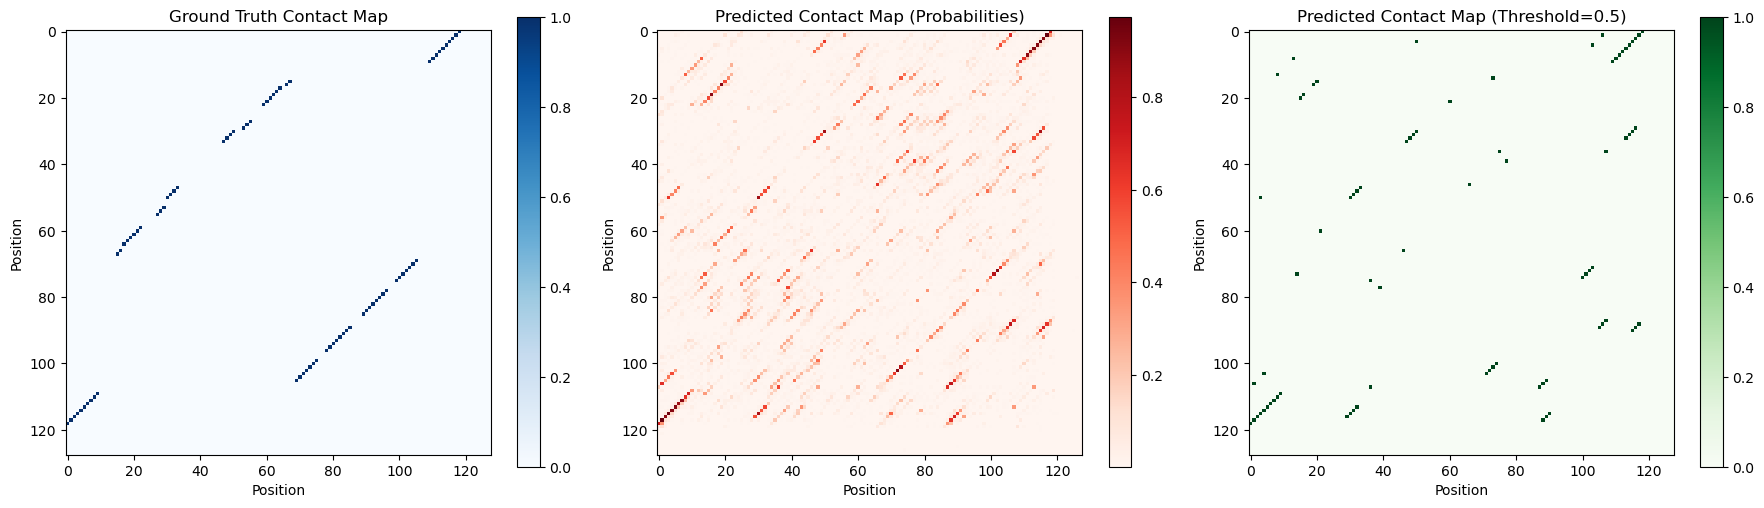


Sample Metrics: F1=0.4750, Recall=0.4750
True pairs: 80
Predicted pairs (threshold=0.5): 80


In [31]:
test_iter = iter(test_loader)
batch_x, batch_y = next(test_iter)
batch_x, batch_y = batch_x.to(device), batch_y.to(device)

with torch.no_grad():
    predictions = model(batch_x)

sample_idx = 0
true_contact = batch_y[sample_idx].cpu().numpy()
pred_contact = predictions[sample_idx].cpu().numpy()
pred_contact_binary = (pred_contact > 0.5).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].imshow(true_contact, cmap='Blues', interpolation='nearest')
axes[0].set_title('Ground Truth Contact Map')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Position')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pred_contact, cmap='Reds', interpolation='nearest')
axes[1].set_title('Predicted Contact Map (Probabilities)')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Position')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(pred_contact_binary, cmap='Greens', interpolation='nearest')
axes[2].set_title('Predicted Contact Map (Threshold=0.5)')
axes[2].set_xlabel('Position')
axes[2].set_ylabel('Position')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('contact_map_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

f1_sample, recall_sample, _ = calculate_metrics(
    predictions[sample_idx:sample_idx+1], 
    batch_y[sample_idx:sample_idx+1]
)
print(f'\nSample Metrics: F1={f1_sample:.4f}, Recall={recall_sample:.4f}')
print(f'True pairs: {int(true_contact.sum())}')
print(f'Predicted pairs (threshold=0.5): {int(pred_contact_binary.sum())}')

### 4.3 Discussion and Conclusion

Limitations of the CNN model:
1. Limited receptive field: With only 3x3 kernels, the model struggles to capture long-range dependencies between distant bases that form pairs
2. Fixed maximum length (128): Truncates longer sequences, losing potentially important structural information
3. No sequential processing: Unlike RNNs or Transformers, CNNs don't inherently model the sequential nature of RNA
4. Symmetry enforcement is post-hoc: The model learns to predict contacts but symmetry is manually enforced rather than built into the architecture

Proposed improvements:
1. Dilated convolutions or larger receptive fields: Use dilated convolutions with increasing dilation rates to capture long-range dependencies without increasing parameters significantly
2. Attention mechanisms: Add self-attention layers to explicitly model relationships between distant positions, similar to Transformer architectures used in recent RNA folding models
3. Data augmentation: Apply sequence reversal, complement generation, and random cropping to artificially increase training data and improve generalization

In [26]:
print("Assignment 2 Complete!")
print(f"Final Results - Test F1: {avg_test_f1:.4f}, Test AUC: {avg_test_auc:.4f}")

Assignment 2 Complete!
Final Results - Test F1: 0.3024, Test AUC: 0.9609
